In [320]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

sales = pd.read_csv("sales_train_validation.csv")
cal = pd.read_csv("calendar.csv")
price = pd.read_csv("sell_prices.csv")

print("Sales:", sales.shape)
print("Calendar:", cal.shape)
print("Prices:", price.shape)

display(sales.head())
display(cal.head())
display(price.head())

Sales: (30490, 1919)
Calendar: (1969, 14)
Prices: (6841121, 4)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [321]:
# Get all day columns from sales data
d_cols = [col for col in sales.columns if col.startswith("d_")]

# Total sales per day across all products and stores
daily_sales = sales[d_cols].sum(axis=0)

# Convert to dataframe
ts_df = pd.DataFrame({
    "d": d_cols,
    "sales": daily_sales.values
})

# Add real dates from calendar
calendar_dates = cal[["d", "date"]].copy()
calendar_dates["date"] = pd.to_datetime(calendar_dates["date"])

ts_df = ts_df.merge(calendar_dates, on="d", how="left")
ts_df = ts_df.sort_values("date")

# Create final time series
ts = ts_df.set_index("date")["sales"]

display(ts_df.head())
display(ts_df.tail())

,d,sales,date
0,d_1,32631,2011-01-29
1,d_2,31749,2011-01-30
2,d_3,23783,2011-01-31
3,d_4,25412,2011-02-01
4,d_5,19146,2011-02-02


,d,sales,date
1908,d_1909,35343,2016-04-20
1909,d_1910,35033,2016-04-21
1910,d_1911,40517,2016-04-22
1911,d_1912,48962,2016-04-23
1912,d_1913,49795,2016-04-24


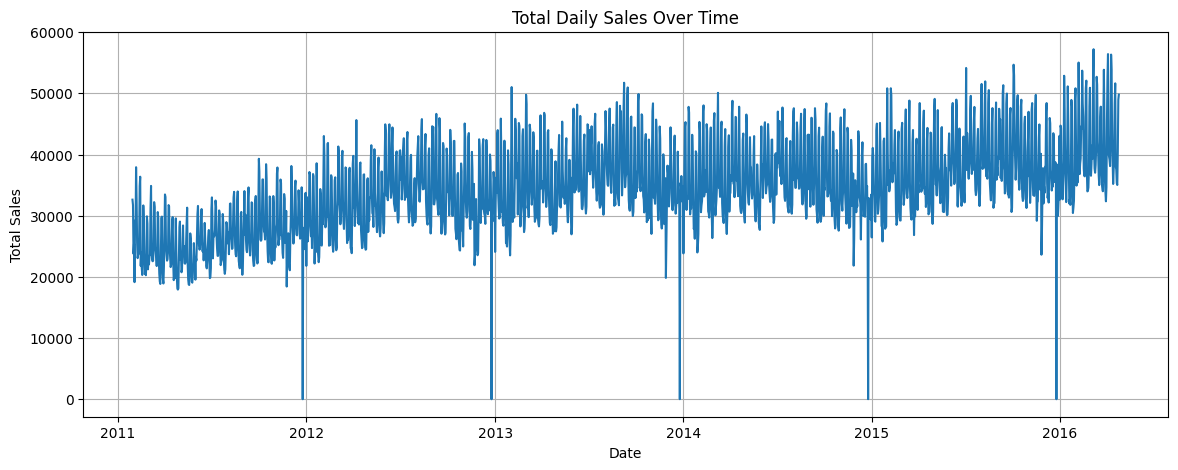

In [322]:
plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts.values)
plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

In [323]:
# Last 28 days as test period
test_size = 28

train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())
print("Train size:", len(train))
print("Test size:", len(test))

Train period: 2011-01-29 00:00:00 to 2016-03-27 00:00:00
Test period: 2016-03-28 00:00:00 to 2016-04-24 00:00:00
Train size: 1885
Test size: 28


In [324]:
def calculate_metrics(y_true, y_pred, model_name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Avoid division by zero in MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1))) * 100

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

In [325]:
def plot_forecast_with_uncertainty(train, test, prediction, lower_bound, upper_bound, model_name, last_days=28):
    prediction = np.array(prediction, dtype=float)
    lower_bound = np.array(lower_bound, dtype=float)
    upper_bound = np.array(upper_bound, dtype=float)

    train_zoom = train.iloc[-last_days:]

    plt.figure(figsize=(14, 6))

    plt.plot(train_zoom.index, train_zoom.values, label=f"Training Data Last {last_days} Days")
    plt.plot(test.index, test.values, label="Actual Test Data", marker="o")
    plt.plot(test.index, prediction, label="Predicted Values", marker="o", linestyle="--")

    plt.fill_between(
        test.index,
        lower_bound,
        upper_bound,
        alpha=0.2,
        label="95% Prediction Interval"
    )

    plt.axvline(x=test.index[0], color="black", linestyle="--", label="Forecast Start")

    plt.title(f"Forecast Uncertainty - {model_name}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [326]:
def plot_forecast_zoom(train, test, prediction, model_name):
    prediction = np.array(prediction, dtype=float)

    # Only for visualization, not for training
    train_zoom = train.iloc[-28:]

    plt.figure(figsize=(14, 6))

    plt.plot(
        train_zoom.index,
        train_zoom.values,
        label="Training Data (Last 28 Days)",
        linewidth=2
    )

    plt.plot(
        test.index,
        test.values,
        label="Actual Test Data",
        marker="o",
        linewidth=2
    )

    plt.plot(
        test.index,
        prediction,
        label="Predicted Values",
        marker="o",
        linestyle="--",
        linewidth=2
    )

    plt.axvline(
        x=test.index[0],
        color="black",
        linestyle="--",
        label="Forecast Start"
    )

    plt.title(f"Forecast Visualization: {model_name}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()

In [327]:
def evaluate_uncertainty(y_true, lower_bound, upper_bound, model_name):
    y_true = np.array(y_true, dtype=float)
    lower_bound = np.array(lower_bound, dtype=float)
    upper_bound = np.array(upper_bound, dtype=float)

    coverage = np.mean((y_true >= lower_bound) & (y_true <= upper_bound)) * 100
    avg_interval_width = np.mean(upper_bound - lower_bound)

    return {
        "Model": model_name,
        "Interval Coverage (%)": coverage,
        "Average Interval Width": avg_interval_width
    }

In [353]:
# Pinball loss for one quantile
def pinball_loss(y_true, y_quantile_pred, quantile):
    y_true = np.array(y_true, dtype=float)
    y_quantile_pred = np.array(y_quantile_pred, dtype=float)

    error = y_true - y_quantile_pred

    loss = np.maximum(
        quantile * error,
        (quantile - 1) * error
    )

    return np.mean(loss)
def scaled_pinball_loss(y_true, y_quantile_pred, quantile, train_series):
    # scale based on average absolute change in training data
    scale = np.mean(np.abs(np.diff(train_series.values)))

    if scale == 0:
        scale = 1e-8

    pl = pinball_loss(y_true, y_quantile_pred, quantile)

    return pl / scale

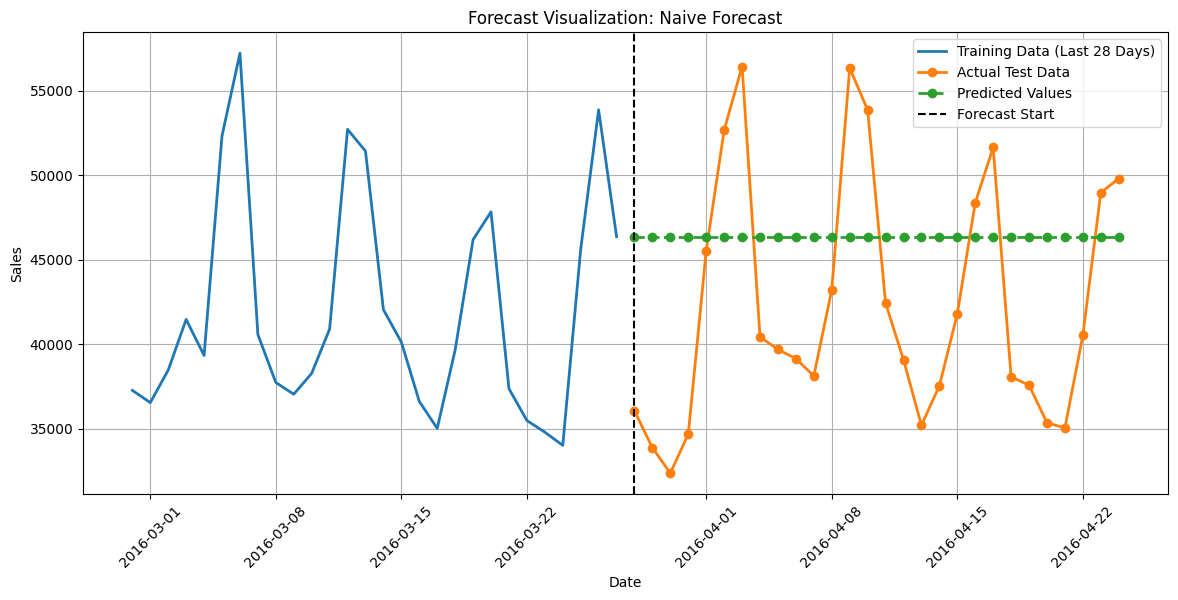

In [328]:
# Naive forecast: future value = last observed training value
naive_pred = np.repeat(train.iloc[-1], len(test))

plot_forecast_zoom(train, test, naive_pred, "Naive Forecast")

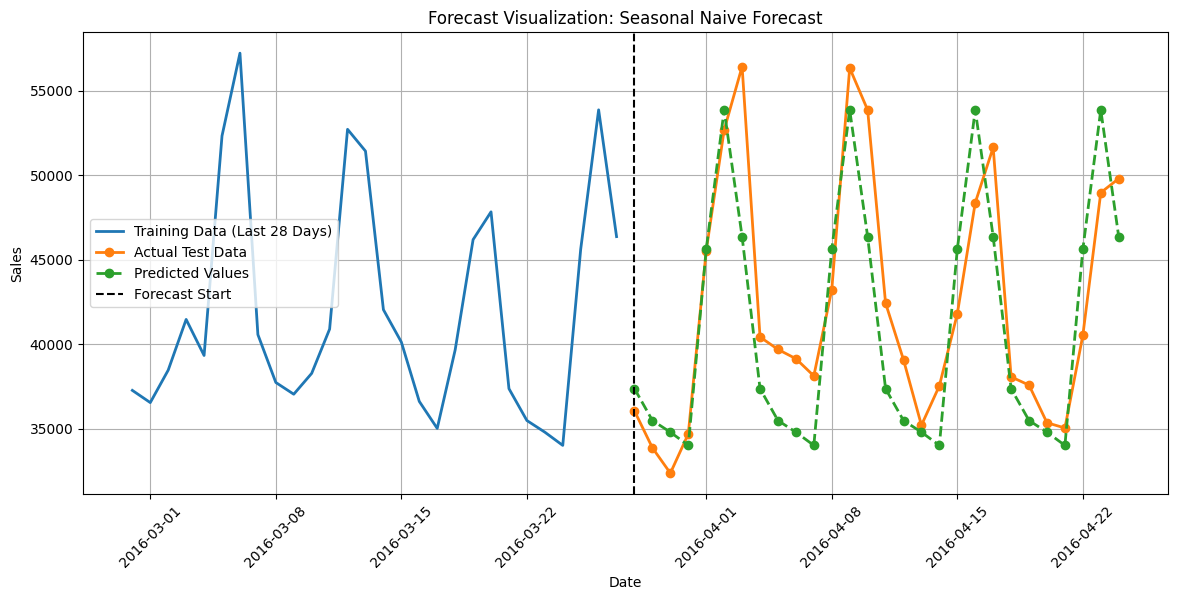

In [329]:
# Seasonal naive forecast: repeat last 7-day weekly pattern
seasonal_period = 7

seasonal_naive_pred = []

for i in range(len(test)):
    seasonal_naive_pred.append(train.iloc[-seasonal_period + (i % seasonal_period)])

seasonal_naive_pred = np.array(seasonal_naive_pred)

plot_forecast_zoom(train, test, seasonal_naive_pred, "Seasonal Naive Forecast")

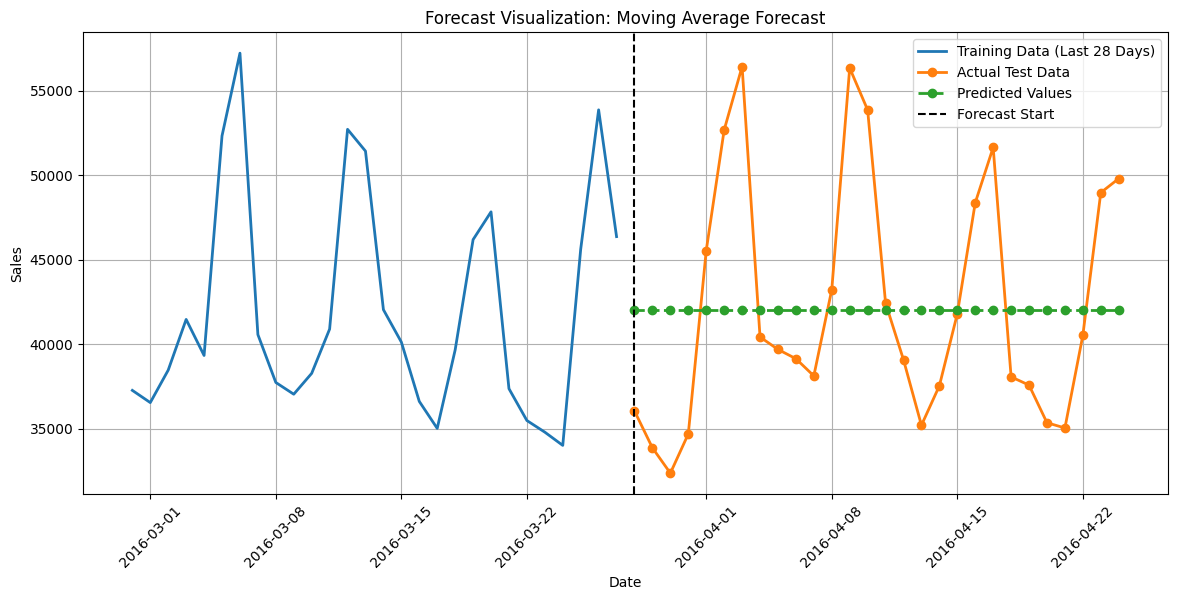

In [330]:
moving_avg_value = train.iloc[-28:].mean()
moving_avg_pred = np.repeat(moving_avg_value, len(test))
plot_forecast_zoom(train, test, moving_avg_pred, "Moving Average Forecast")

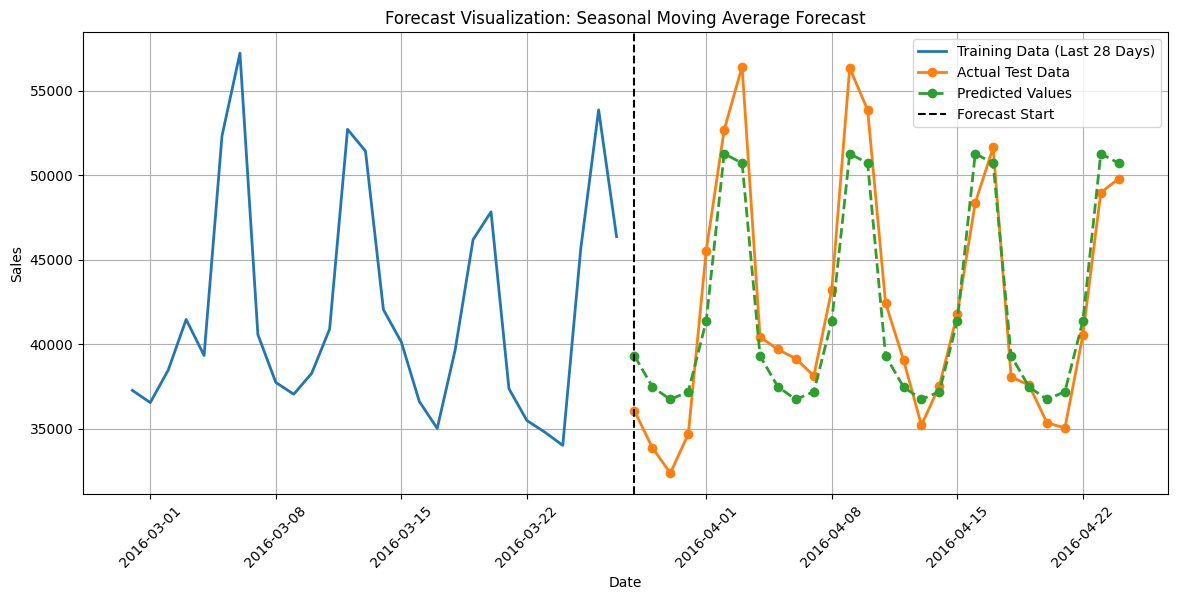

In [331]:
# Seasonal Moving Average Forecast
# Average of same weekday from last 4 weeks

seasonal_period = 7
weeks = 4

seasonal_ma_pred = []

for i in range(len(test)):
    weekday_position = i % seasonal_period
    
    same_weekday_values = train.iloc[-seasonal_period * weeks + weekday_position :: seasonal_period]
    
    forecast = same_weekday_values.mean()
    seasonal_ma_pred.append(forecast)

seasonal_ma_pred = np.array(seasonal_ma_pred)

plot_forecast_zoom(train, test, seasonal_ma_pred, "Seasonal Moving Average Forecast")

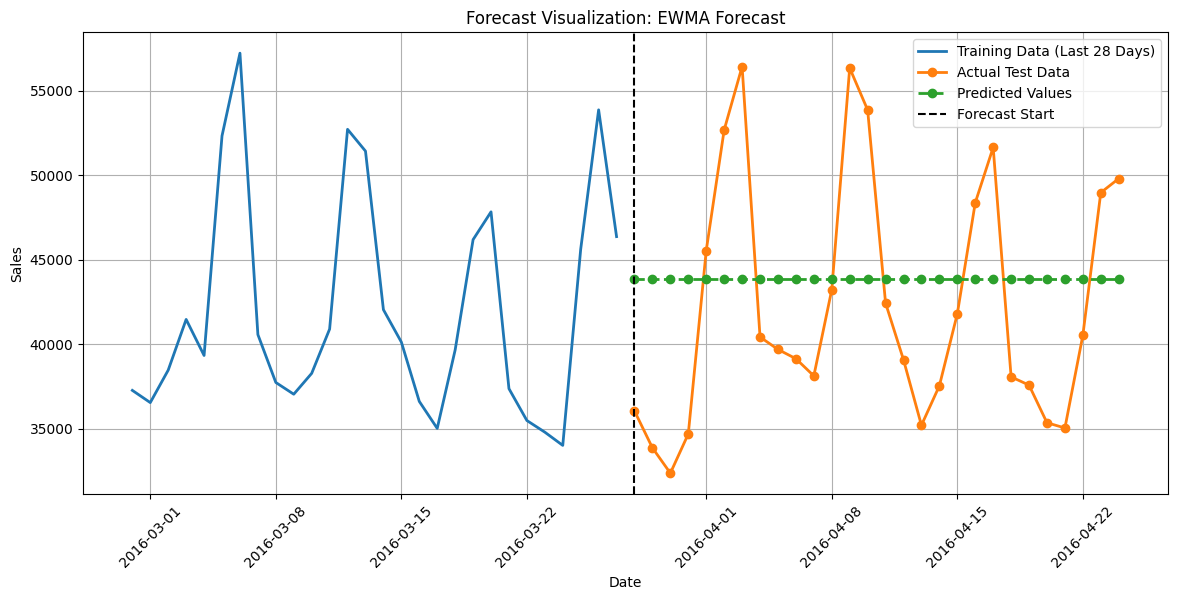

In [332]:
# EWMA Forecast
ewma_series = train.shift(1).ewm(alpha=0.3).mean()

# Use last EWMA value as forecast for test period
ewma_value = ewma_series.iloc[-1]
ewma_pred = np.repeat(ewma_value, len(test))

plot_forecast_zoom(train, test, ewma_pred, "EWMA Forecast")

c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


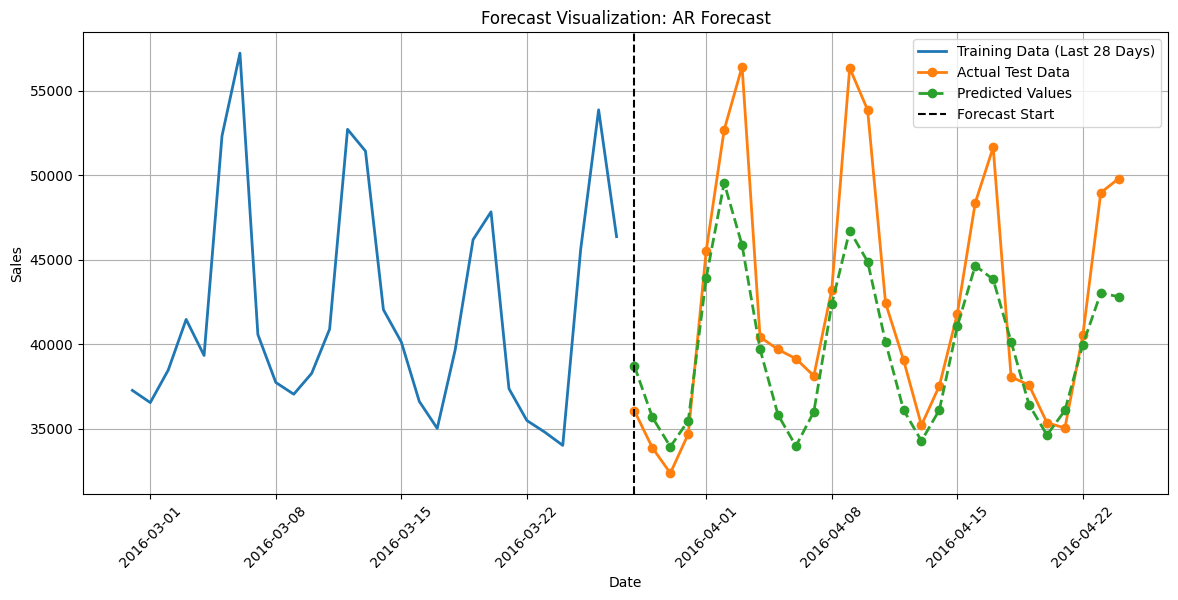

In [333]:
from statsmodels.tsa.arima.model import ARIMA

ar_model = ARIMA(train, order=(7, 0, 0))
ar_fit = ar_model.fit()

ar_pred = ar_fit.forecast(steps=len(test))
ar_pred = np.maximum(ar_pred, 0)

plot_forecast_zoom(train, test, ar_pred, "AR Forecast")

c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


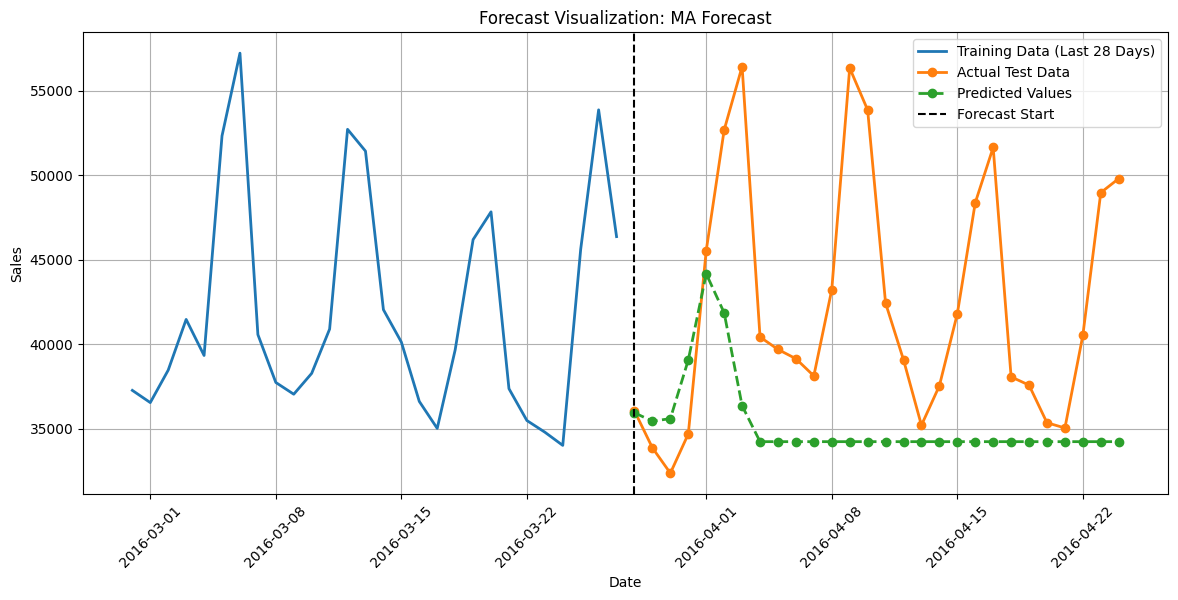

In [334]:
ma_model = ARIMA(train, order=(0, 0, 7))
ma_fit = ma_model.fit()

ma_pred = ma_fit.forecast(steps=len(test))
ma_pred = np.maximum(ma_pred, 0)

plot_forecast_zoom(train, test, ma_pred, "MA Forecast")

c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


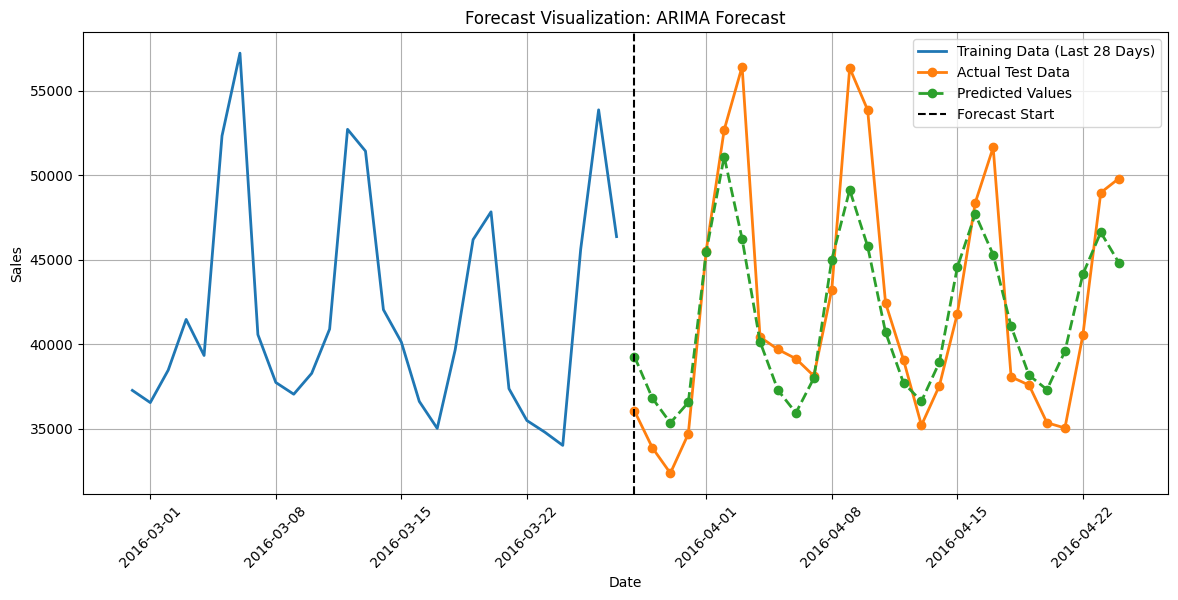

In [335]:
arima_model = ARIMA(train, order=(7, 1, 1))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

# Sales cannot be negative
arima_pred = np.maximum(arima_pred, 0)

plot_forecast_zoom(train, test, arima_pred, "ARIMA Forecast")

c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


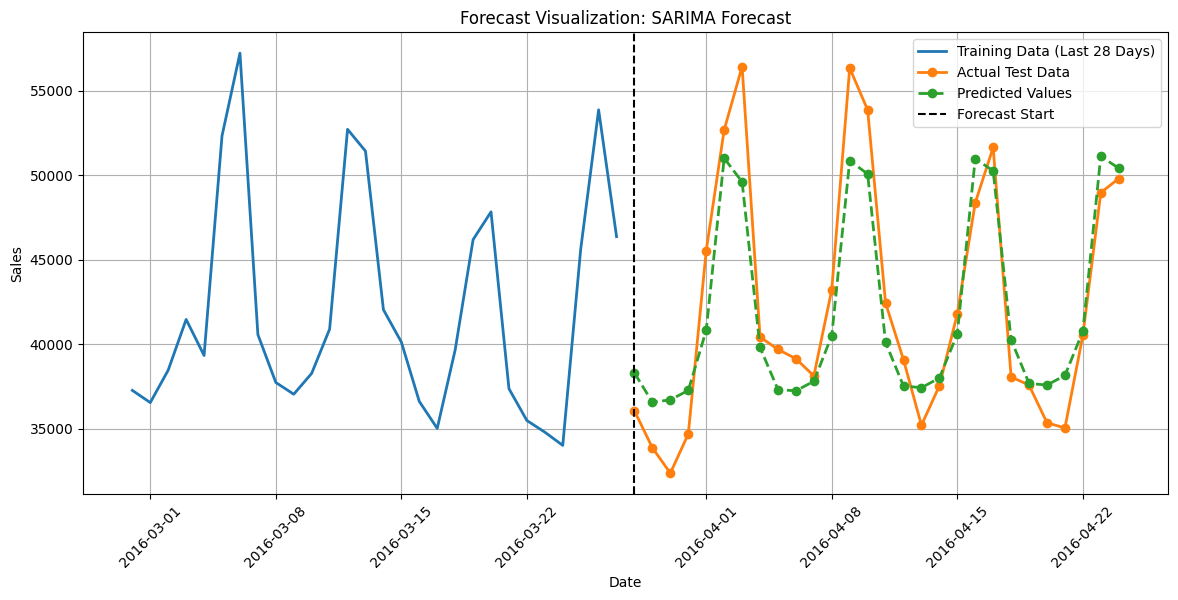

In [336]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_pred = sarima_fit.forecast(steps=len(test))
sarima_pred = np.maximum(sarima_pred, 0)

plot_forecast_zoom(train, test, sarima_pred, "SARIMA Forecast")

c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Ishant\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


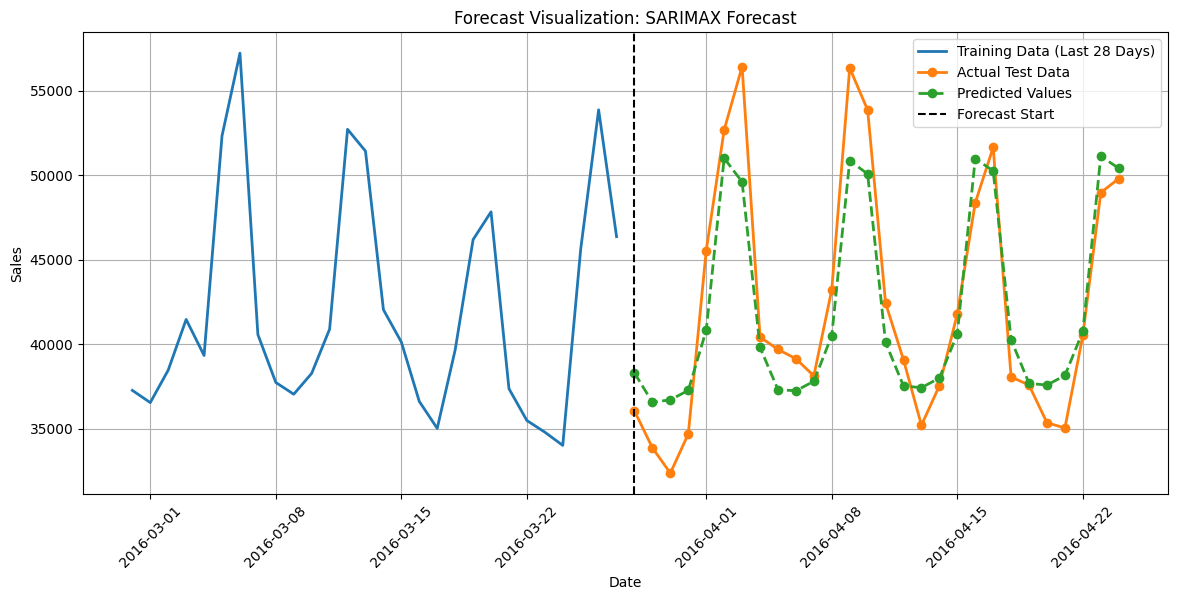

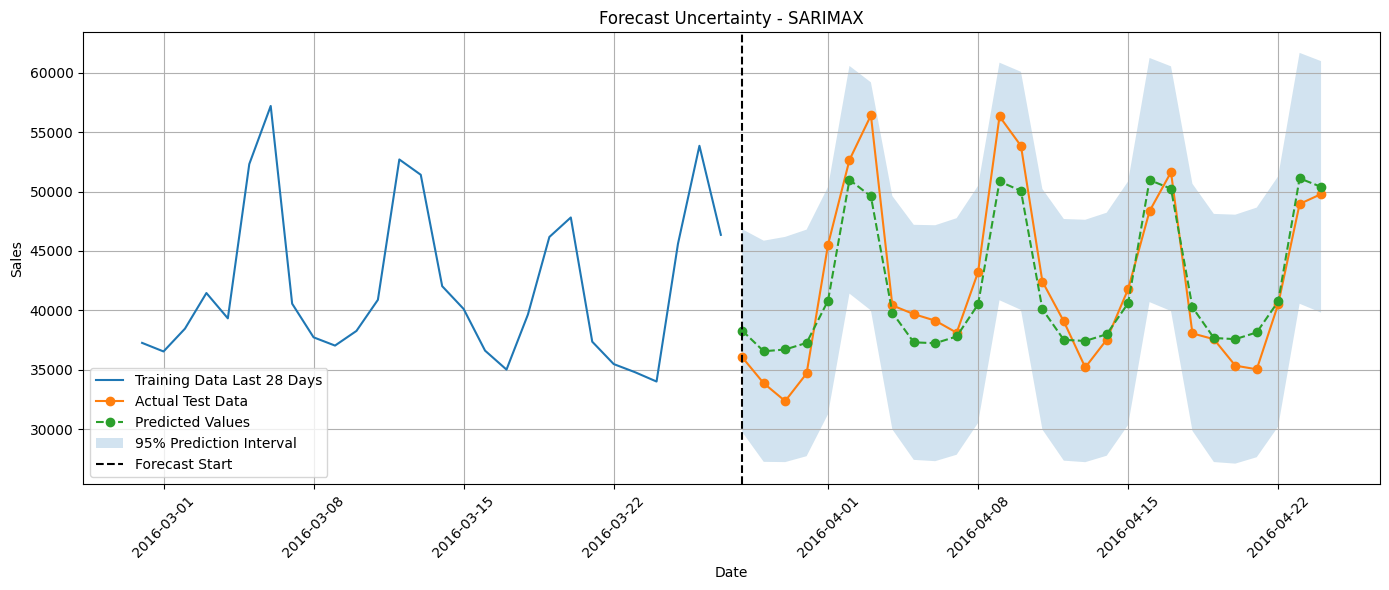

Test length: 28
Prediction length: 28
Lower bound length: 28
Upper bound length: 28


In [337]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMAX Forecast
# order = non-seasonal ARIMA part
# seasonal_order = weekly seasonality part because daily data has 7-day cycle

sarimax_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)
sarimax_forecast = sarimax_fit.get_forecast(steps=len(test))


# Predicted mean for test period
sarimax_pred = sarimax_forecast.predicted_mean
sarimax_pred = np.maximum(sarimax_pred, 0)

plot_forecast_zoom(train, test, sarimax_pred, "SARIMAX Forecast")

sarimax_conf_int = sarimax_forecast.conf_int(alpha=0.05)

sarimax_lower = np.maximum(sarimax_conf_int.iloc[:, 0], 0)
sarimax_upper = np.maximum(sarimax_conf_int.iloc[:, 1], 0)
plot_forecast_with_uncertainty(
    train=train,
    test=test,
    prediction=sarimax_pred,
    lower_bound=sarimax_lower,
    upper_bound=sarimax_upper,
    model_name="SARIMAX",
    last_days=28
)

print("Test length:", len(test))
print("Prediction length:", len(sarimax_pred))
print("Lower bound length:", len(sarimax_lower))
print("Upper bound length:", len(sarimax_upper))

In [352]:
# SARIMAX gives:
# sarimax_lower = lower uncertainty bound
# sarimax_pred  = predicted mean / central forecast
# sarimax_upper = upper uncertainty bound

wspl_results = []

wspl_results.append({
    "Model": "SARIMAX",
    "Quantile": 0.025,
    "Scaled Pinball Loss": scaled_pinball_loss(
        test,
        sarimax_lower,
        0.025,
        train
    )
})

wspl_results.append({
    "Model": "SARIMAX",
    "Quantile": 0.50,
    "Scaled Pinball Loss": scaled_pinball_loss(
        test,
        sarimax_pred,
        0.50,
        train
    )
})

wspl_results.append({
    "Model": "SARIMAX",
    "Quantile": 0.975,
    "Scaled Pinball Loss": scaled_pinball_loss(
        test,
        sarimax_upper,
        0.975,
        train
    )
})

wspl_table = pd.DataFrame(wspl_results)
display(wspl_table)

,Model,Quantile,Scaled Pinball Loss
0,SARIMAX,0.025,0.060795
1,SARIMAX,0.500,0.271572
2,SARIMAX,0.975,0.056987


18:19:47 - cmdstanpy - INFO - Chain [1] start processing
18:19:47 - cmdstanpy - INFO - Chain [1] done processing


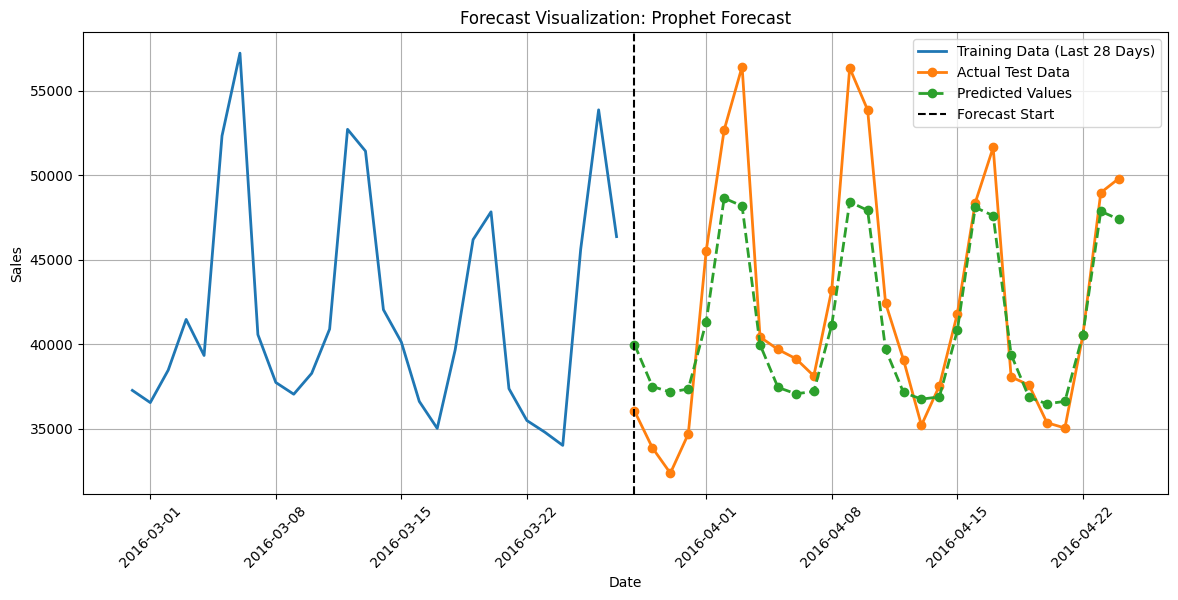

In [338]:

from prophet import Prophet
# Prepare data for Prophet
prophet_df = ts.reset_index()
prophet_df.columns = ["ds", "y"]

# Split same as your Task 2 split
prophet_train = prophet_df.iloc[:-test_size]
prophet_test = prophet_df.iloc[-test_size:]

# Create Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train model
prophet_model.fit(prophet_train)

# Create future dataframe for test period
future = prophet_model.make_future_dataframe(
    periods=len(prophet_test),
    freq="D"
)

# Forecast
prophet_forecast = prophet_model.predict(future)

# Take only test period predictions
prophet_pred = prophet_forecast["yhat"].iloc[-len(prophet_test):].values

# Sales cannot be negative
prophet_pred = np.maximum(prophet_pred, 0)

plot_forecast_zoom(train, test, prophet_pred, "Prophet Forecast")

In [339]:
classical_results = []

classical_results.append(calculate_metrics(test, naive_pred, "Naive Forecast"))
classical_results.append(calculate_metrics(test, seasonal_naive_pred, "Seasonal Naive"))
classical_results.append(calculate_metrics(test, moving_avg_pred, "Moving Average"))
classical_results.append(calculate_metrics(test, ewma_pred, "EWMA"))
classical_results.append(calculate_metrics(test, seasonal_ma_pred, "Seasonal Moving Average"))
classical_results.append(calculate_metrics(test, ar_pred, "AR"))
classical_results.append(calculate_metrics(test, ma_pred, "MA"))
classical_results.append(calculate_metrics(test, arima_pred, "ARIMA"))
classical_results.append(calculate_metrics(test, sarimax_pred, "SARIMAX"))
classical_results.append(calculate_metrics(test, prophet_pred, "Prophet"))

classical_result_table = pd.DataFrame(classical_results).round(4)
display(classical_result_table)

,Model,MAE,RMSE,MAPE (%)
0,Naive Forecast,7457.0714,8184.1069,18.8748
1,Seasonal Naive,3231.1429,3947.4781,7.3545
2,Moving Average,5959.2270,7095.3267,13.8993
3,EWMA,6507.0311,7266.7940,15.8142
4,Seasonal Moving Average,2199.5000,2619.6855,5.2227
5,AR,3279.9757,4401.2333,7.1139
6,MA,7675.6950,10012.5338,16.4570
7,ARIMA,2950.7575,3819.1869,6.7077
8,SARIMAX,2309.7981,2794.9442,5.4401
9,Prophet,2630.7325,3371.9036,6.0252


In [ ]:
best_classical_model = classical_result_table.sort_values("RMSE").iloc[0]

print("Best Classical Forecasting Model:")
print(best_classical_model)

Best Classical Forecasting Model:
Model       Seasonal Moving Average
MAE                          2199.5
RMSE                      2619.6855
MAPE (%)                     5.2227
Name: 4, dtype: object


In [ ]:
sarimax_uncertainty_result = evaluate_uncertainty(
    y_true=test,
    lower_bound=sarimax_lower,
    upper_bound=sarimax_upper,
    model_name="SARIMAX"
)


uncertainty_table = pd.DataFrame([sarimax_uncertainty_result]).round(4)

task2_predictions = pd.DataFrame({
    "date": test.index,
    "actual": test.values,
    "naive": naive_pred,
    "moving_average": moving_avg_pred,
    "ewma": ewma_pred,
    "seasonal_naive": seasonal_naive_pred,
    "arima": arima_pred,
    "sarimax": sarimax_pred,
    "prophet": prophet_pred
})